In [ ]:
!pip install pandas

In [ ]:
!pip install seaborn

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_rows', 1000)


current_path = os.getcwd()
directory = os.path.join(current_path) + "/../data/"
tot_dataframe = pd.DataFrame()
for root,dirs,files in os.walk(directory):
    for file in files:
       if file.endswith(".csv"):
          csv_path=directory+file
          data = pd.read_csv(csv_path)
          df = pd.DataFrame(data)
          tot_dataframe = pd.concat([tot_dataframe,df])

input_size = tot_dataframe['size'] * 2 + tot_dataframe['size'] # As I need to take as input a vector of SIZE elements of half, and a vector of INT8, hence size * 3
output_size = tot_dataframe['size'] * 4 # The output is in float, hence SIZE elements of 32 bits
tot_dataframe['mem_bytes'] = (tot_dataframe['size'] * (2 + 1))  + tot_dataframe['size'] * 4

tot_dataframe['bandwidth_mbps'] = (tot_dataframe['mem_bytes']) / (tot_dataframe['time_us']) #MB/s
tot_dataframe["density"] = ["$%s$" % x for x in tot_dataframe["density"]]



/scratch/gsorrentino/tcuscan/temp_segscan_profile_integration/pytorch-tcuscan/paper-plots/../data/
/scratch/gsorrentino/tcuscan/temp_segscan_profile_integration/pytorch-tcuscan/paper-plots/../data/bench_results_seg_scan_sc_0.7_fp16.csv
/scratch/gsorrentino/tcuscan/temp_segscan_profile_integration/pytorch-tcuscan/paper-plots/../data/bench_results_seg_scan_sc_0.3_fp16.csv
/scratch/gsorrentino/tcuscan/temp_segscan_profile_integration/pytorch-tcuscan/paper-plots/../data/bench_results_seg_scan_sc_0.1_fp16.csv
/scratch/gsorrentino/tcuscan/temp_segscan_profile_integration/pytorch-tcuscan/paper-plots/../data/bench_results_seg_scan_sc_0.4_fp16.csv
/scratch/gsorrentino/tcuscan/temp_segscan_profile_integration/pytorch-tcuscan/paper-plots/../data/bench_results_seg_scan_sc_0.0_fp16.csv
/scratch/gsorrentino/tcuscan/temp_segscan_profile_integration/pytorch-tcuscan/paper-plots/../data/bench_results_seg_scan_sc_0.001_fp16.csv
/scratch/gsorrentino/tcuscan/temp_segscan_profile_integration/pytorch-tcuscan

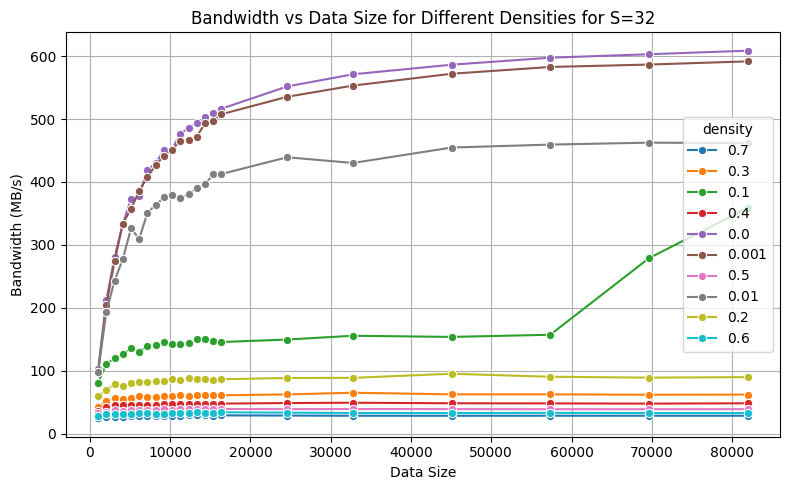

In [2]:

filtered_32 = tot_dataframe[tot_dataframe["s"]==32]

plt.figure(figsize=(8, 5))
sns.lineplot(x='size', y='bandwidth_mbps', hue='density', data=filtered_32, marker='o')

plt.xlabel('Data Size')
plt.ylabel('Bandwidth (MB/s)')
plt.title('Bandwidth vs Data Size for Different Densities for S=32')
plt.tight_layout()

plt.grid(True)
filename = "./segmented/"+"s_32.pdf"
plt.savefig(filename)
plt.show()


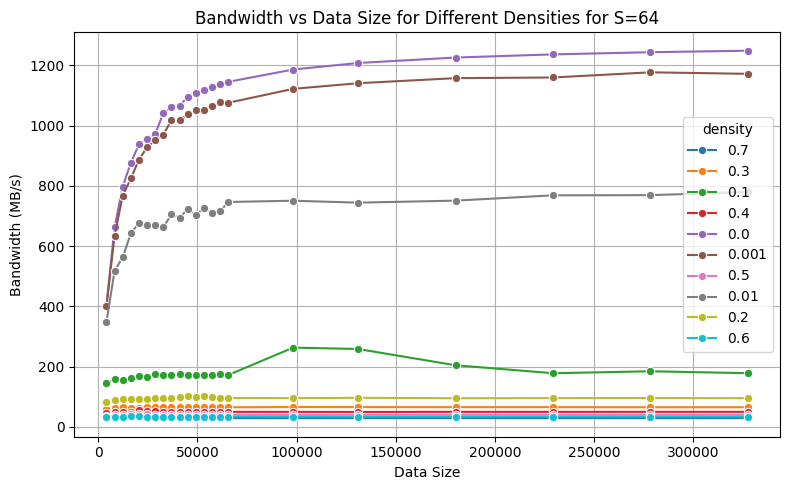

In [3]:

filtered_32 = tot_dataframe[tot_dataframe["s"]==64]

plt.figure(figsize=(8, 5))
sns.lineplot(x='size', y='bandwidth_mbps', hue='density', data=filtered_32, marker='o')

plt.xlabel('Data Size')
plt.ylabel('Bandwidth (MB/s)')
plt.title('Bandwidth vs Data Size for Different Densities for S=64')
plt.tight_layout()

plt.grid(True)
filename = "./segmented/"+"s_64.pdf"
plt.savefig(filename)
plt.show()

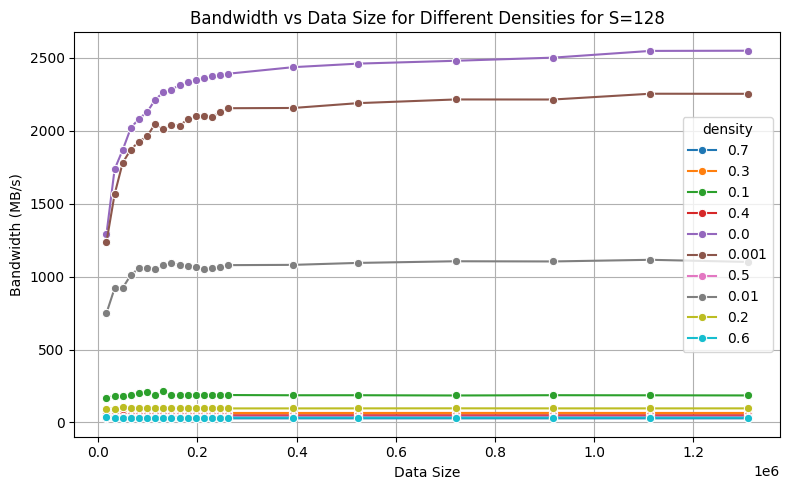

In [4]:

filtered_32 = tot_dataframe[tot_dataframe["s"]==128]

plt.figure(figsize=(8, 5))
sns.lineplot(x='size', y='bandwidth_mbps', hue='density', data=filtered_32, marker='o')

plt.xlabel('Data Size')
plt.ylabel('Bandwidth (MB/s)')
plt.title('Bandwidth vs Data Size for Different Densities for S=128')
plt.tight_layout()

plt.grid(True)
filename = "./segmented/"+"s_128.pdf"
plt.savefig(filename)
plt.show()
